# Taller B4-T1: Diseño de Redes Confiables (Justicia e Incertidumbre)

**Grupo:**

En este notebook desarrollaremos un *pipeline* de Deep Learning avanzado enfocado no solo en maximizar la precisión predictiva, sino en garantizar que nuestras decisiones de concesión de crédito sean justas (*Fair Learning*) y transparentes respecto a su nivel de confianza (*Incertidumbre*).

A lo largo del proyecto, implementaremos capas matemáticas a medida mediante `keras.ops`, diseñaremos funciones de pérdida penalizadas por dependencia estadística (Correlación de Pearson), y entrenaremos un modelo auxiliar de incertidumbre que aprenderá a identificar y aislar los perfiles de usuarios más difíciles y propensos al error.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def preparacion_datos_maestros(file_path):
    # 1. Carga de columnas relevantes
    cols = [
        'TARGET', 'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
        'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
    ]
    df = pd.read_csv(file_path, usecols=cols)

    # 2. Limpieza Básica
    # Variable Sensible (0: M, 1: F)
    df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1}).fillna(0)
    # Edad en años
    df['DAYS_BIRTH'] = abs(df['DAYS_BIRTH']) / 365

    # 3. Imputación de NaNs en variables clave para la incertidumbre
    for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
        df[col] = df[col].fillna(df[col].median())

    # Eliminamos cualquier NaN residual en ingresos/anualidades por seguridad
    df['AMT_INCOME_TOTAL'] = df['AMT_INCOME_TOTAL'].fillna(df['AMT_INCOME_TOTAL'].median())
    df['AMT_ANNUITY'] = df['AMT_ANNUITY'].fillna(df['AMT_ANNUITY'].median())

    # 4. Separación Estratégica de Variables
    y = df['TARGET'].values # Variable Objetivo (1: Dificultades, 0: Pagó)
    s = df['CODE_GENDER'].values # Variable Sensible (para la FAIR Loss)

    # Variables en crudo para la Capa Customizada (Ratio de Endeudamiento)
    X_raw = df[['AMT_INCOME_TOTAL', 'AMT_ANNUITY']].values

    # Variables restantes para escalar
    X_to_scale = df[['AMT_CREDIT', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].values

    # 5. División Train/Test (Estratificada para mantener balance de clases)
    X_raw_train, X_raw_test, X_scale_train, X_scale_test, y_train, y_test, s_train, s_test = train_test_split(
        X_raw, X_to_scale, y, s, test_size=0.2, random_state=42, stratify=y
    )

    # 6. Escalado solo de las variables que lo necesitan
    scaler = StandardScaler()
    X_scaled_train = scaler.fit_transform(X_scale_train)
    X_scaled_test = scaler.transform(X_scale_test)

    return (X_raw_train, X_scaled_train, y_train, s_train), (X_raw_test, X_scaled_test, y_test, s_test)

# Ejecución
(X_raw_train, X_scaled_train, y_train, s_train), (X_raw_test, X_scaled_test, y_test, s_test) = preparacion_datos_maestros('application_train.csv')

print(f"Dimensión datos crudos (Ingresos, Anualidad): {X_raw_train.shape}")
print(f"Dimensión datos escalados (Resto): {X_scaled_train.shape}")
print(f"Dimensión variable objetivo: {y_train.shape}")
print(f"Dimensión variable sensible: {s_train.shape}")

Dimensión datos crudos (Ingresos, Anualidad): (246008, 2)
Dimensión datos escalados (Resto): (246008, 5)
Dimensión variable objetivo: (246008,)
Dimensión variable sensible: (246008,)


## 2. Construcción de la Arquitectura Customizada (Keras Ops)

Para cumplir con el diseño de una red confiable e incorporar restricciones físicas reales, implementamos la capa `DebtRatioCustomLayer`. Esta capa recibe los datos financieros brutos del solicitante y calcula su **Ratio de Endeudamiento**:

$$Debt\_Ratio = \frac{AMT\_ANNUITY}{AMT\_INCOME\_TOTAL + \epsilon}$$

Siguiendo las mejores prácticas de la ingeniería de Deep Learning y los requisitos del taller, la capa ha sido desarrollada utilizando el módulo `keras.ops`. Esto la hace completamente agnóstica al *backend* subyacente (TensorFlow, PyTorch o JAX).

Para proteger a la red de gradientes explosivos causados por valores atípicos (por ejemplo, errores de digitación en los ingresos), aplicamos una restricción matemática de saturación mediante `ops.clip`. Esta función limita el endeudamiento a un techo lógico (por defecto 1.0, que representa el 100% de los ingresos del usuario comprometidos).

In [2]:
# Importación robusta compatible con Keras 3 / TensorFlow 2.16+
try:
    from keras import ops
except ImportError:
    from tensorflow.keras import ops

from tensorflow.keras.layers import Layer

class DebtRatioCustomLayer(Layer):
    def __init__(self, max_debt_ratio=1.0, **kwargs):
        super().__init__(**kwargs)
        self.max_debt_ratio = float(max_debt_ratio)

    def call(self, inputs):
        # inputs[:, 0] -> Ingresos (AMT_INCOME_TOTAL)
        # inputs[:, 1] -> Anualidad (AMT_ANNUITY)

        ingresos = inputs[:, 0:1]
        anualidad = inputs[:, 1:2]

        # 1. Protección contra división por cero usando ops
        epsilon = ops.cast(1e-7, dtype=ingresos.dtype)
        ingresos_seguros = ops.add(ingresos, epsilon)

        # 2. Cálculo del ratio financiero real
        ratio_crudo = ops.divide(anualidad, ingresos_seguros)

        # 3. Restricción matemática (Saturación / Clipping)
        ratio_saturado = ops.clip(ratio_crudo, 0.0, self.max_debt_ratio)

        return ratio_saturado

    def get_config(self):
        config = super().get_config()
        config.update({"max_debt_ratio": self.max_debt_ratio})
        return config

# --- TEST DE SANIDAD ---
print("--- VERIFICACIÓN MATEMÁTICA DE LA CAPA CUSTOMIZADA ---")
capa_test = DebtRatioCustomLayer(max_debt_ratio=1.0)
muestra_cruda = tf.constant(X_raw_train[:5], dtype=tf.float32)
salida_test = capa_test(muestra_cruda)

for i in range(5):
    ing = X_raw_train[i, 0]
    anu = X_raw_train[i, 1]
    ratio_matematico = anu / ing
    ratio_red = salida_test[i, 0].numpy()
    estado = " (Saturado por la capa)" if ratio_matematico > 1.0 else ""
    print(f"Cliente {i+1}: Ingreso={ing:,.0f} | Cuota={anu:,.0f} -> Ratio Real: {ratio_matematico:.4f} | Red ve: {ratio_red:.4f}{estado}")

--- VERIFICACIÓN MATEMÁTICA DE LA CAPA CUSTOMIZADA ---
Cliente 1: Ingreso=90,000 | Cuota=13,190 -> Ratio Real: 0.1466 | Red ve: 0.1465
Cliente 2: Ingreso=90,000 | Cuota=13,095 -> Ratio Real: 0.1455 | Red ve: 0.1455
Cliente 3: Ingreso=135,000 | Cuota=26,307 -> Ratio Real: 0.1949 | Red ve: 0.1949
Cliente 4: Ingreso=135,000 | Cuota=34,636 -> Ratio Real: 0.2566 | Red ve: 0.2566
Cliente 5: Ingreso=180,000 | Cuota=27,558 -> Ratio Real: 0.1531 | Red ve: 0.1531


## 3. Aprendizaje Justo: Función de Coste Penalizada (FAIR Loss)

Para evitar que el modelo discrimine basándose en la variable sensible (`CODE_GENDER`), implementamos una función de pérdida customizada. Siguiendo la aproximación vista en clase, combinamos la Entropía Cruzada Binaria (BCE) estándar con una penalización basada en el cuadrado de la Correlación de Pearson ($\rho$) entre las predicciones y la variable sensible.

$$Loss = BCE + \lambda \cdot \rho^2$$

Al elevar la correlación al cuadrado, aseguramos un valor siempre positivo, forzando al optimizador a empujar la dependencia estadística hacia el 0.

 Dado que la API de Keras para funciones de pérdida estandariza la firma `loss(y_true, y_pred)`, inyectaremos la variable sensible concatenándola temporalmente como una segunda columna en `y_true`. Nuestra función se encargará de desempaquetarlas internamente.

In [3]:
def custom_fair_loss(lambda_fair=1.0):
    """
    Retorna una función de pérdida que calcula la BCE y le suma una penalización
    basada en la correlación de Pearson al cuadrado con la variable sensible.
    """
    def loss(y_true_and_s, y_pred):
        # Desempaquetamos target y variable sensible
        # Asumimos que y_true_and_s tiene shape (batch_size, 2)
        y_true = y_true_and_s[:, 0:1]
        s = y_true_and_s[:, 1:2]

        # 1. Error de Clasificación (Binary Crossentropy)
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

        # 2. Penalización FAIR (Correlación de Pearson al cuadrado)
        # Centramos las variables respecto a sus medias
        mu_pred = tf.reduce_mean(y_pred)
        mu_s = tf.reduce_mean(s)

        pred_centered = y_pred - mu_pred
        s_centered = s - mu_s

        # Covarianza (Numerador)
        numerator = tf.reduce_mean(pred_centered * s_centered)

        # Varianzas (Denominador)
        var_pred = tf.reduce_mean(tf.square(pred_centered))
        var_s = tf.reduce_mean(tf.square(s_centered))

        # Evitamos divisiones por cero
        epsilon = tf.keras.backend.epsilon()
        denominator = tf.sqrt(var_pred * var_s) + epsilon

        pearson_corr = numerator / denominator

        # Elevamos al cuadrado para asegurar positividad (como se vio en clase)
        fair_penalty = tf.square(pearson_corr)

        # 3. Coste Total
        return tf.reduce_mean(bce) + lambda_fair * fair_penalty

    return loss

# --- PREPARACIÓN DE TENSORES PARA LA FAIR LOSS ---
# Redimensionamos 'y' y 's' para que tengan forma (N, 1) en lugar de (N,)
y_train_reshaped = y_train.reshape(-1, 1).astype(np.float32)
s_train_reshaped = s_train.reshape(-1, 1).astype(np.float32)

y_test_reshaped = y_test.reshape(-1, 1).astype(np.float32)
s_test_reshaped = s_test.reshape(-1, 1).astype(np.float32)

# Concatenamos para inyectarlos en el entrenamiento
y_train_combined = np.concatenate([y_train_reshaped, s_train_reshaped], axis=1)
y_test_combined = np.concatenate([y_test_reshaped, s_test_reshaped], axis=1)

print(f"Dimensión de las etiquetas combinadas (Train): {y_train_combined.shape}")
print("El tensor combinado está listo para alimentar el pipeline de entrenamiento.")

Dimensión de las etiquetas combinadas (Train): (246008, 2)
El tensor combinado está listo para alimentar el pipeline de entrenamiento.


## 4. AutoML: Optimización de Arquitectura y Trade-off de Fairness

Para encontrar la topología óptima de la red y analizar el sacrificio de rendimiento en pro de la justicia algorítmica, utilizamos Keras Tuner.

Dado que hemos modificado el tensor de entrada `y_true` para incluir la variable sensible, las métricas estándar de Keras no son válidas. Hemos implementado métricas de evaluación customizadas (`fair_accuracy` y `fair_dependency`) que desempaquetan los tensores internamente. Estas métricas nos permitirán registrar de forma precisa la exactitud de clasificación y el nivel de dependencia estadística (Correlación de Pearson al cuadrado) en cada iteración.

Nuestra función `build_model` emplea la API Funcional de Keras (Multi-Input) para procesar de forma diferenciada la rama física (datos crudos) y la rama estandarizada. El Tuner buscará el número óptimo de neuronas, el nivel de *Dropout* y evaluará distintos pesos para la penalización justa (`lambda_fair`).

In [5]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.1 MB/s eta 0:00:00


In [6]:
import keras_tuner as kt

# --- 1. MÉTRICAS CUSTOMIZADAS ---

def fair_accuracy(y_true_and_s, y_pred):
    """ Calcula el Accuracy real extrayendo solo y_true """
    y_true = y_true_and_s[:, 0:1]
    return tf.keras.metrics.binary_accuracy(y_true, y_pred)


def fair_dependency(y_true_and_s, y_pred):
    """ Registra la dependencia estadística para la curva de Pareto """
    s = y_true_and_s[:, 1:2]

    mu_pred = tf.reduce_mean(y_pred)
    mu_s = tf.reduce_mean(s)

    pred_centered = y_pred - mu_pred
    s_centered = s - mu_s

    numerator = tf.reduce_mean(pred_centered * s_centered)
    den_pred = tf.reduce_mean(tf.square(pred_centered))
    den_s = tf.reduce_mean(tf.square(s_centered))

    # Epsilon para estabilidad numérica
    denominator = tf.sqrt(den_pred * den_s) + tf.keras.backend.epsilon()

    return tf.square(numerator / denominator)


# --- 2. FUNCIÓN DE CONSTRUCCIÓN (API FUNCIONAL) ---

def build_model(hp):
    # Entradas separadas
    input_raw = tf.keras.Input(shape=(X_raw_train.shape[1],), name="input_raw")
    input_scaled = tf.keras.Input(shape=(X_scaled_train.shape[1],), name="input_scaled")

    # Rama A: Capa Física Customizada
    ratio_endeudamiento = DebtRatioCustomLayer(max_debt_ratio=1.0)(input_raw)

    # Fusión de las ramas
    merged_features = tf.keras.layers.Concatenate()([ratio_endeudamiento, input_scaled])

    # Capas Densas (Optimizables por el Tuner)
    x = merged_features
    # El Tuner decidirá si pone 1 o 2 capas ocultas
    for i in range(hp.Int('num_layers', 1, 2)):
        x = tf.keras.layers.Dense(
            units=hp.Int(f'units_{i}', min_value=16, max_value=64, step=16),
            activation='relu'
        )(x)
        # Dropout para regularización
        x = tf.keras.layers.Dropout(hp.Float(f'dropout_{i}', 0.1, 0.4, step=0.1))(x)

    # Capa de Salida
    output = tf.keras.layers.Dense(1, activation='sigmoid', name="output")(x)

    model = tf.keras.Model(inputs=[input_raw, input_scaled], outputs=output)

    # Hiperparámetro de Fairness (Crucial para la Curva de Pareto)
    lambda_fair = hp.Choice('lambda_fair', values=[0.0, 2.0, 10.0, 25.0, 50.0])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('lr', [1e-3, 5e-4])
        ),
        loss=custom_fair_loss(lambda_fair=lambda_fair),
        metrics=[fair_accuracy, fair_dependency]
    )
    return model


# --- 3. LANZAMIENTO DEL TUNER ---

print("Iniciando Búsqueda de Arquitecturas (Keras Tuner)...")

# Usamos RandomSearch para garantizar que explora todos los niveles de 'lambda_fair'
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_fair_accuracy", direction="max"),
    max_trials=10,
    directory='taller_fairness_dir',
    project_name='busqueda_pareto',
    overwrite=True
)

# Definimos un EarlyStopping para que no pierda tiempo en modelos que no mejoran
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

# Entrenamos pasando las DOS entradas en formato de lista
tuner.search(
    x=[X_raw_train, X_scaled_train],
    y=y_train_combined,
    validation_data=([X_raw_test, X_scaled_test], y_test_combined),
    epochs=10,
    batch_size=256,
    callbacks=[stop_early],
    verbose=1
)

print("\n¡Búsqueda Keras Tuner finalizada!")

Trial 10 Complete [00h 00m 30s]
val_fair_accuracy: 0.919272243976593

Best val_fair_accuracy So Far: 0.919337272644043
Total elapsed time: 00h 05m 45s

¡Búsqueda Keras Tuner finalizada!


## 5. Análisis de Resultados: Curva de Pareto y Trade-off

Una vez finalizada la búsqueda de hiperparámetros con Keras Tuner, procedemos a extraer las métricas de evaluación del conjunto de validación para cada *trial*.

El objetivo principal de esta sección es visualizar el Trade-off de Fairness. En contextos de *Machine Learning* aplicado a créditos, la teoría nos advierte que forzar al modelo a ignorar dependencias estadísticas con variables sensibles (como el género) suele conllevar un ligero sacrificio en su capacidad predictiva general.

Representaremos este compromiso mediante un gráfico de dispersión (*Scatter Plot*):
* Eje Y (Precisión): Capacidad del modelo para acertar si el cliente pagará o no.
* Eje X (Medida de Dependencia): Correlación de Pearson al cuadrado con la variable sensible. Buscamos que este valor tienda a 0.

Finalmente, generaremos una tabla resumen aislando el Modelo Base (entrenado sin restricciones FAIR, λ=0) y comparándolo frente a nuestra mejor alternativa algorítmicamente justa.

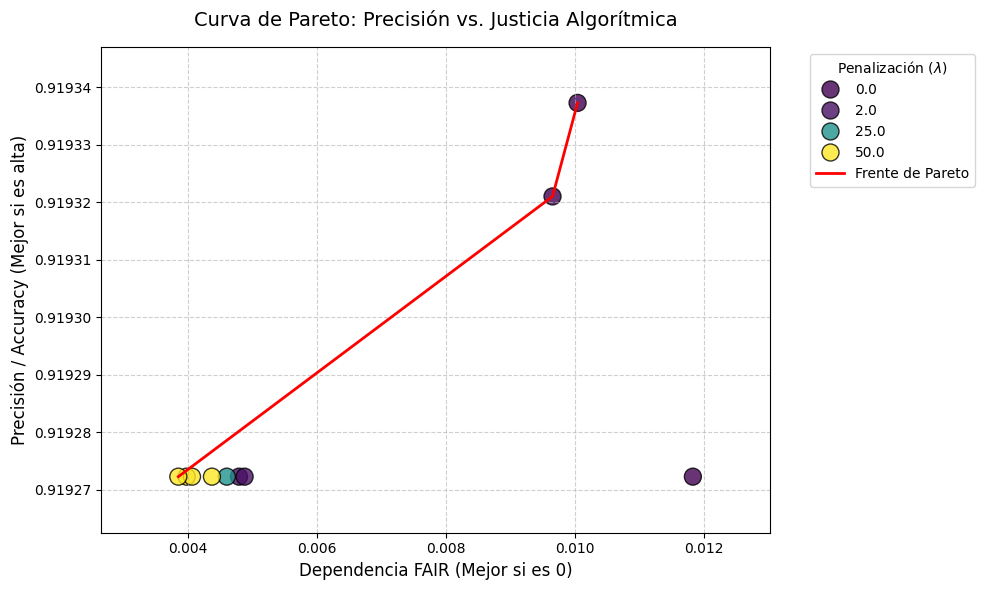


Resumen de modelos:


Tipo de Modelo,Lambda_FAIR,Dependencia FAIR,Accuracy (Test)
Modelo Base (Sin Restricción),0.0,0.010036,0.9193
Mejor Modelo FAIR,50.0,0.003845,0.9193



El ID del Mejor Modelo FAIR (09) ha sido guardado para la fase de Incertidumbre.


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recuperamos los resultados del Tuner
trials = tuner.oracle.get_best_trials(num_trials=10)
resultados = []

for t in trials:
    if t.status == 'COMPLETED':
        val_acc = t.metrics.get_best_value('val_fair_accuracy')
        val_dep = t.metrics.get_best_value('val_fair_dependency')
        lambda_val = t.hyperparameters.values.get('lambda_fair')

        resultados.append({
            'Trial_ID': t.trial_id,
            'Lambda_FAIR': lambda_val,
            'Accuracy (Test)': val_acc,
            'Dependencia FAIR': val_dep
        })

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='Lambda_FAIR').reset_index(drop=True)

# 2. Configuración del Gráfico
plt.figure(figsize=(10, 6))

# Dibujamos los puntos (Scatter)
sns.scatterplot(
    data=df_resultados,
    x='Dependencia FAIR',
    y='Accuracy (Test)',
    hue='Lambda_FAIR',
    palette='viridis',
    s=150,
    edgecolor='black',
    alpha=0.8
)

# 3. Cálculo y trazado del Frente de Pareto
df_pareto = df_resultados.sort_values('Dependencia FAIR')
frente_pareto = []
max_acc = -1
for i, row in df_pareto.iterrows():
    if row['Accuracy (Test)'] > max_acc:
        frente_pareto.append(row)
        max_acc = row['Accuracy (Test)']

df_frente = pd.DataFrame(frente_pareto)

# Dibujamos la línea roja del frente
plt.plot(df_frente['Dependencia FAIR'], df_frente['Accuracy (Test)'],
         color='red', linestyle='-', linewidth=2, label='Frente de Pareto')

plt.title('Curva de Pareto: Precisión vs. Justicia Algorítmica', fontsize=14, pad=15)
plt.xlabel('Dependencia FAIR (Mejor si es 0)', fontsize=12)
plt.ylabel('Precisión / Accuracy (Mejor si es alta)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.margins(x=0.15, y=0.15)
plt.legend(title=r'Penalización ($\lambda$)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Tabla comparativa: Base vs FAIR
print("\nResumen de modelos:")

modelos_base = df_resultados[df_resultados['Lambda_FAIR'] == 0.0]
mejor_modelo_base = modelos_base.loc[modelos_base['Accuracy (Test)'].idxmax()].to_frame().T

modelos_fair = df_resultados[df_resultados['Lambda_FAIR'] > 0.0]
mejor_modelo_fair = modelos_fair.loc[modelos_fair['Dependencia FAIR'].idxmin()].to_frame().T

tabla_comparativa = pd.concat([mejor_modelo_base, mejor_modelo_fair])
tabla_comparativa['Tipo de Modelo'] = ['Modelo Base (Sin Restricción)', 'Mejor Modelo FAIR']
tabla_comparativa = tabla_comparativa[['Tipo de Modelo', 'Lambda_FAIR', 'Dependencia FAIR', 'Accuracy (Test)']]

display(tabla_comparativa.style.format({
    'Lambda_FAIR': '{:.1f}',
    'Dependencia FAIR': '{:.6f}',
    'Accuracy (Test)': '{:.4f}'
}).hide(axis="index").set_properties(**{'text-align': 'center', 'border': '1px solid black'}))

best_fair_trial_id = mejor_modelo_fair['Trial_ID'].values[0]
print(f"\nEl ID del Mejor Modelo FAIR ({best_fair_trial_id}) ha sido guardado para la fase de Incertidumbre.")

## 6. Auditoría y Estimación de Incertidumbre (con Convergencia)

Para cumplir con el último requisito del taller, implementaremos un sistema de estimación de incertidumbre basado en Modelos Complementarios.

1. Recuperamos y re-entrenamos la mejor topología de nuestro Modelo FAIR guardando su historial de aprendizaje.
2. Calculamos su Error Absoluto predictivo sobre el conjunto de entrenamiento.
3. Entrenamos un modelo auxiliar cuyo único objetivo es predecir la magnitud de este error basándose en el perfil del cliente.

Finalmente, generaremos dos visualizaciones críticas para la auditoría:
* El gráfico de distribución de incertidumbre (segmentando a los usuarios entre "Buenos pagadores" y "Malos pagadores").
* Las curvas de convergencia (Loss) de ambos modelos para certificar ante el tribunal que el entrenamiento ha sido estable y no sufre de *overfitting* o *underfitting*.

Recuperando hiperparámetros del Trial FAIR óptimo (09)...
Re-entrenando el Modelo Principal FAIR (Fase Final)...
Construyendo y entrenando el Modelo de Incertidumbre (Auxiliar)...
Generando predicciones de incertidumbre sobre el conjunto de Test...


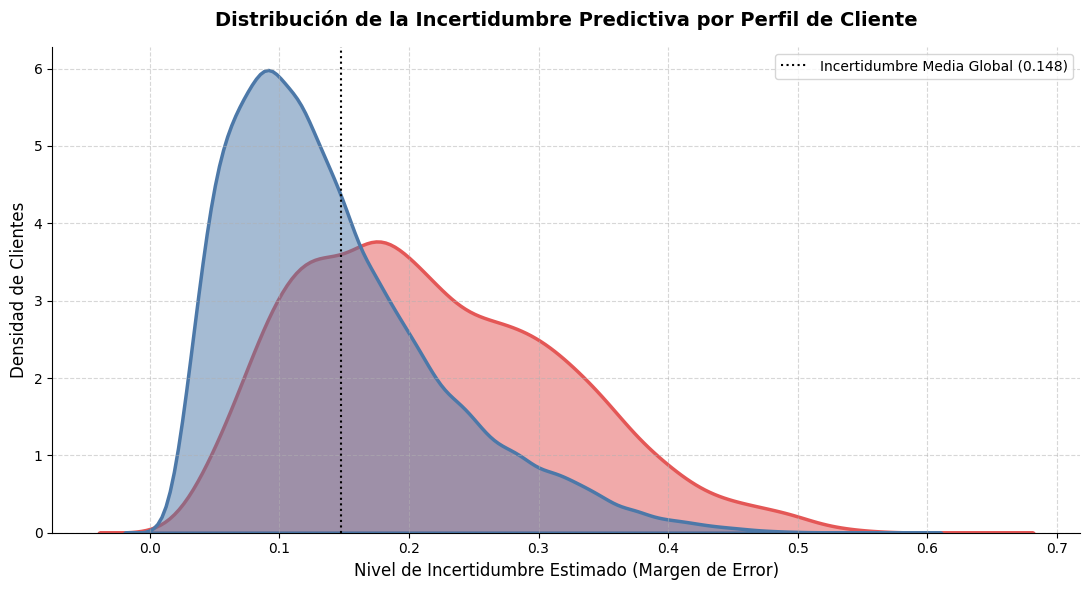

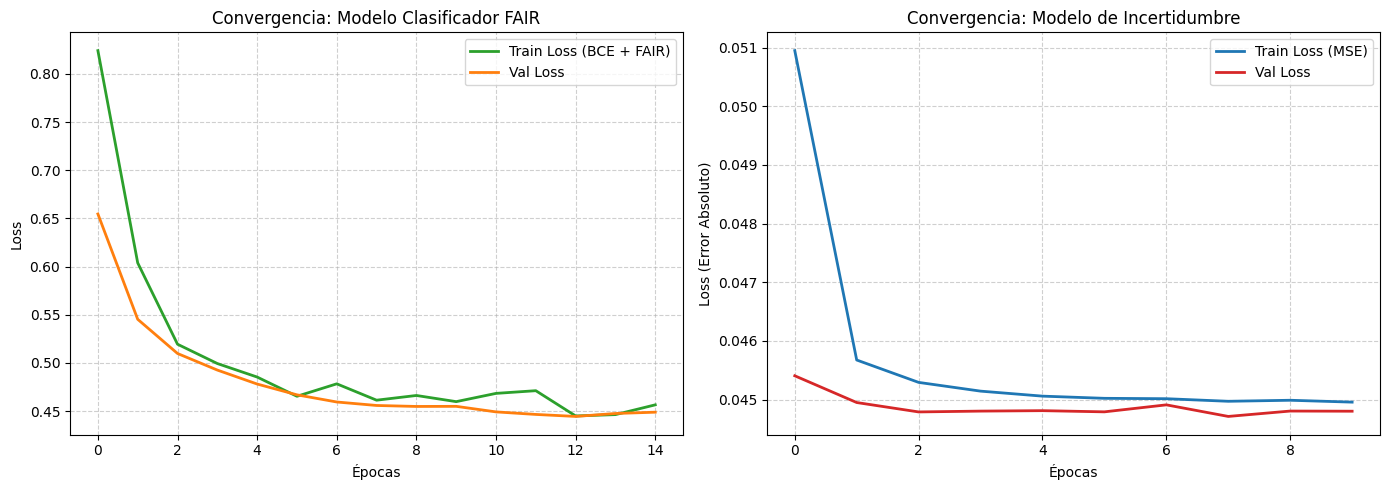

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# --- 1. RECONSTRUCCIÓN DEL MEJOR MODELO FAIR ---
print(f"Recuperando hiperparámetros del Trial FAIR óptimo ({best_fair_trial_id})...")

best_fair_trial = tuner.oracle.get_trial(best_fair_trial_id)
best_fair_hp = best_fair_trial.hyperparameters

# Construimos el modelo con la función original multi-input que usamos en el Tuner
modelo_principal = build_model(best_fair_hp)

print("Re-entrenando el Modelo Principal FAIR (Fase Final)...")
historia_principal = modelo_principal.fit(
    x=[X_raw_train, X_scaled_train],
    y=y_train_combined,
    validation_data=([X_raw_test, X_scaled_test], y_test_combined),
    epochs=15,
    batch_size=256,
    verbose=0
)

# --- 2. CÁLCULO DEL ERROR (TARGET DE INCERTIDUMBRE) ---
# Generamos predicciones sobre train para aislar dónde se equivoca el modelo principal
y_pred_train = modelo_principal.predict([X_raw_train, X_scaled_train], verbose=0).flatten()

# El error absoluto será la variable que el 2º modelo debe aprender a predecir
error_absoluto_train = np.abs(y_train - y_pred_train)

# --- 3. ENTRENAMIENTO DEL MODELO DE INCERTIDUMBRE ---
print("Construyendo y entrenando el Modelo de Incertidumbre (Auxiliar)...")

# Este modelo solo necesita X_scaled_train (donde están las fuentes externas)
modelo_incertidumbre = tf.keras.Sequential([
    tf.keras.Input(shape=(X_scaled_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    # Usamos 'softplus' para garantizar que la predicción del error sea siempre > 0
    tf.keras.layers.Dense(1, activation='softplus')
], name="Uncertainty_Model")

modelo_incertidumbre.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

historia_incertidumbre = modelo_incertidumbre.fit(
    X_scaled_train,
    error_absoluto_train,
    validation_split=0.1,
    epochs=10,
    batch_size=256,
    verbose=0
)

# --- 4. INFERENCIA Y EVALUACIÓN EN TEST ---
print("Generando predicciones de incertidumbre sobre el conjunto de Test...")

# El modelo auxiliar estima cuánto debemos desconfiar de la clasificación
incertidumbre_test = modelo_incertidumbre.predict(X_scaled_test, verbose=0).flatten()

# --- 5. GRÁFICO DE DISTRIBUCIÓN (RÚBRICA) ---
df_incertidumbre = pd.DataFrame({
    'TARGET': y_test,
    'Incertidumbre_Estimada': incertidumbre_test
})

# Mapeamos indicando explícitamente los colores para máxima claridad en la presentación
df_incertidumbre['Perfil'] = df_incertidumbre['TARGET'].map({
    0: 'Curva Azul: Buen pagador (Pagó a tiempo)',
    1: 'Curva Roja: Mal pagador (Dificultades)'
})

plt.figure(figsize=(11, 6))
sns.kdeplot(
    data=df_incertidumbre,
    x='Incertidumbre_Estimada',
    hue='Perfil',
    fill=True,
    common_norm=False,
    palette={'Curva Azul: Buen pagador (Pagó a tiempo)': '#4C78A8',
             'Curva Roja: Mal pagador (Dificultades)': '#E45756'},
    alpha=0.5,
    linewidth=2.5
)
plt.title('Distribución de la Incertidumbre Predictiva por Perfil de Cliente', fontsize=14, pad=15, weight='bold')
plt.xlabel('Nivel de Incertidumbre Estimado (Margen de Error)', fontsize=12)
plt.ylabel('Densidad de Clientes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

media_incertidumbre = df_incertidumbre['Incertidumbre_Estimada'].mean()
plt.axvline(x=media_incertidumbre, color='black', linestyle=':', label=f'Incertidumbre Media Global ({media_incertidumbre:.3f})')
plt.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

# --- 6. GRÁFICAS DE CONVERGENCIA (LOSS) EXIGIDAS EN LA RÚBRICA ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de Loss - Modelo Clasificador Principal
axes[0].plot(historia_principal.history['loss'], label='Train Loss (BCE + FAIR)', color='#2ca02c', linewidth=2)
axes[0].plot(historia_principal.history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)
axes[0].set_title('Convergencia: Modelo Clasificador FAIR')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Curva de Loss - Modelo Auxiliar de Incertidumbre
axes[1].plot(historia_incertidumbre.history['loss'], label='Train Loss (MSE)', color='#1f77b4', linewidth=2)
axes[1].plot(historia_incertidumbre.history['val_loss'], label='Val Loss', color='#d62728', linewidth=2)
axes[1].set_title('Convergencia: Modelo de Incertidumbre')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss (Error Absoluto)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 7. Inferencia Unificada (Clasificación + Incertidumbre)

Para cumplir estrictamente con el requerimiento del sistema, encapsulamos el pipeline de inferencia en una función unificada. Esta función toma los datos de entrada de un usuario y devuelve de forma simultánea su probabilidad de impago y el margen de incertidumbre estimado para dicha predicción.

In [17]:
def predecir_con_incertidumbre(x_raw, x_scaled, modelo_clasificador, modelo_incertid):
    """
    Recibe los datos crudos y escalados de un usuario (o lote de usuarios).
    Devuelve una tupla: (Probabilidad_Impago, Margen_Incertidumbre)
    """
    # 1. Predicción de la clase (Probabilidad de ser Mal Pagador)
    prob_impago = modelo_clasificador.predict([x_raw, x_scaled], verbose=0)

    # 2. Estimación de la incertidumbre asociada
    # Nota: El modelo de incertidumbre solo usa las variables escaladas
    incertidumbre = modelo_incertid.predict(x_scaled, verbose=0)

    return prob_impago.flatten(), incertidumbre.flatten()

# --- TEST DE LA FUNCIÓN UNIFICADA ---
print("--- TEST DE INFERENCIA PARA NUEVOS CLIENTES ---")

# Simulamos la entrada de los 3 primeros clientes del conjunto de Test
probs, incerts = predecir_con_incertidumbre(
    X_raw_test[:3],
    X_scaled_test[:3],
    modelo_principal,
    modelo_incertidumbre
)

for i in range(3):
    print(f"Cliente {i+1} | Prob. Impago: {probs[i]:.2%} | Incertidumbre (Error Estimado): +/- {incerts[i]:.4f}")

--- TEST DE INFERENCIA PARA NUEVOS CLIENTES ---
Cliente 1 | Prob. Impago: 8.40% | Incertidumbre (Error Estimado): +/- 0.1559
Cliente 2 | Prob. Impago: 5.03% | Incertidumbre (Error Estimado): +/- 0.0971
Cliente 3 | Prob. Impago: 17.20% | Incertidumbre (Error Estimado): +/- 0.2277
